In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

BASE = r"C:\Users\Admin\Desktop\AI-Business-Risk-Intelligence"

telco = pd.read_csv(os.path.join(BASE, "data", "processed", "telco_clean.csv"))
bank = pd.read_csv(os.path.join(BASE, "data", "processed", "bank_clean.csv"))

print("✅ Cleaned datasets loaded!")
print(f"Telco: {telco.shape}")
print(f"Bank: {bank.shape}")

✅ Cleaned datasets loaded!
Telco: (7043, 20)
Bank: (10000, 11)


In [2]:
import sys
sys.path.append(BASE)

from src.models.risk_scoring_engine import calculate_risk_score

telco_risk = calculate_risk_score(telco)
print("\n✅ Telco risk scores done!")
print(telco_risk[['risk_score', 'risk_category']].head(10))

⚙️ Calculating risk scores...
✅ Risk scores calculated!

📊 Risk Distribution:
risk_category
Critical    2393
Medium      1751
High        1489
Low         1410
Name: count, dtype: int64

✅ Telco risk scores done!
   risk_score risk_category
0       82.87      Critical
1       49.25        Medium
2       87.91      Critical
3       39.45        Medium
4       91.86      Critical
5       95.16      Critical
6       84.58      Critical
7       77.64          High
8       84.78      Critical
9       32.84        Medium


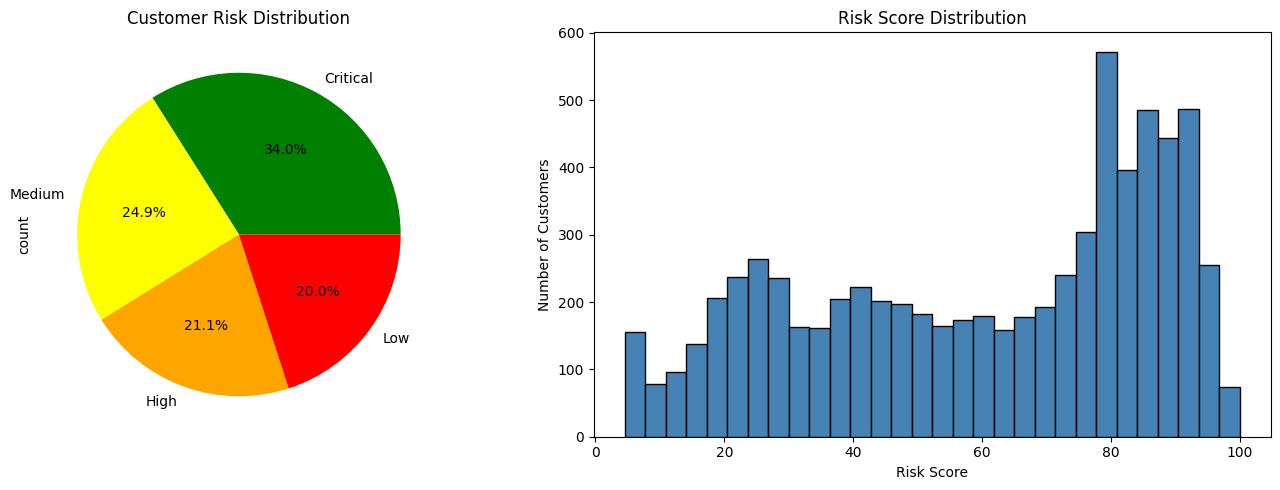

✅ Risk charts displayed!


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk category pie chart
telco_risk['risk_category'].value_counts().plot(
    kind='pie', ax=axes[0],
    colors=['green', 'yellow', 'orange', 'red'],
    autopct='%1.1f%%'
)
axes[0].set_title('Customer Risk Distribution')

# Risk score histogram
axes[1].hist(telco_risk['risk_score'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Risk Score Distribution')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()
print("✅ Risk charts displayed!")

In [4]:
save_path = os.path.join(BASE, "data", "processed")
telco_risk.to_csv(os.path.join(save_path, "telco_risk_scored.csv"), index=False)

print("✅ Risk scored data saved!")
print("🚀 Week 3 Complete — Risk Scoring Engine DONE!")

✅ Risk scored data saved!
🚀 Week 3 Complete — Risk Scoring Engine DONE!
